In [68]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Задание 1

In [ ]:
data = pd.read_csv("song_data.csv")
data.head()

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,Boulevard of Broken Dreams,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,In The End,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,Seven Nation Army,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,By The Way,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,How You Remind Me,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574


In [ ]:
data = data.dropna(
    subset=["song_popularity", "song_duration_ms", "danceability", "energy"]
)

In [17]:
y = data["song_popularity"].values.reshape(-1, 1)
X = np.column_stack(
    [
        np.ones(len(data)),
        data["song_duration_ms"],
        data["danceability"],
        data["energy"],
    ]
)

In [ ]:
n, p = X.shape
beta = np.linalg.solve(X.T @ X, X.T @ y).flatten()
y_pred = X @ beta
residuals = y.flatten() - y_pred
rss = np.sum(residuals**2)
s2 = rss / (n - p)
es_beta = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))

In [ ]:
t_crit = stats.t.ppf(0.975, df=n - p)
ci_lower = beta - t_crit * es_beta
ci_upper = beta + t_crit * es_beta

names = ["bias", "duration_ms", "danceability", "energy"]
for i in range(p):
    print(f"{names[i]:12s}: {beta[i]:7.4f} [{ci_lower[i]:7.4f}, {ci_upper[i]:7.4f}]")

bias        : 44.6097 [42.6403, 46.5790]
duration_ms : -0.0000 [-0.0000,  0.0000]
danceability: 14.4782 [12.4787, 16.4777]
energy      : -0.2567 [-1.7186,  1.2052]


In [ ]:
ci_sigma_lower = np.sqrt((n - p) * s2 / stats.chi2.ppf(0.25, df=n - p))
ci_sigma_upper = np.sqrt((n - p) * s2 / stats.chi2.ppf(0.975, df=n - p))

print(
    f"sigma       : {np.sqrt(s2):7.4f} [{ci_sigma_lower:7.4f}, {ci_sigma_upper:7.4f}]"
)

sigma       : 21.7872 [21.8635, 21.5693]


In [28]:
R2 = 1 - rss / np.sum((y.flatten() - np.mean(y)) ** 2)
print(f"\nR² = {R2:.4f}")


R² = 0.0109


In [ ]:
# Гипотеза 1: beta_energy > 0
t_energy = beta[3] / es_beta[3]

print(
    f"t = {t_energy:.4f}, критическое t = {stats.t.ppf(0.95, df=n - p):.4f}, p-value = {1 - stats.t.cdf(t_energy, df=n - p):.4f}"
)

t = -0.3442, критическое t = 1.6449, p-value = 0.6346


In [ ]:
# Гипотеза 2: beta_duration != 0
t_dur = beta[1] / es_beta[1]

print(
    f"t = {t_dur:.4f}, критическое t = {stats.t.ppf(0.975, df=n - p):.4f}, p-value = {2 * (1 - stats.t.cdf(np.abs(t_dur), df=n - p)):.4f}"
)

t = -1.0641, критическое t = 1.9601, p-value = 0.2873


In [ ]:
# Гипотеза 3: beta_dance = beta_energy = 0 (F-тест)
# Редуцированная модель: только intercept и duration
X_red = np.column_stack([np.ones(n), data["song_duration_ms"].values])
beta_red = np.linalg.solve(X_red.T @ X_red, X_red.T @ y).flatten()
y_pred_red = X_red @ beta_red
rss_red = np.sum((y.flatten() - y_pred_red) ** 2)
n_red, p_red = X_red.shape
F_stat = ((rss_red - rss) / (p - p_red)) / (rss / (n - p))

print(
    f"f = {F_stat:.4f}, критическое f = {stats.f.ppf(0.95, p - p_red, n - p):.4f}, p-value = {1 - stats.f.cdf(F_stat, p - p_red, n - p):.4f}"
)

f = 100.8078, критическое f = 2.9962, p-value = 0.0000


In [40]:
t_dan = beta[2] / es_beta[2]

print(
    f"t = {t_dan:.4f}, критическое t = {stats.t.ppf(0.975, df=n - p):.4f}, p-value = {2 * (1 - stats.t.cdf(np.abs(t_dan), df=n - p)):.4f}"
)

t = 14.1926, критическое t = 1.9601, p-value = 0.0000


# Задание 2

In [53]:
data = pd.read_csv("sex_bmi_smokers.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     1338 non-null   object 
 1   bmi     1338 non-null   float64
 2   smoker  1338 non-null   object 
dtypes: float64(1), object(2)
memory usage: 31.5+ KB


In [ ]:
groups = [
    data["bmi"][data["smoker"] == "yes"].values,
    data["bmi"][data["smoker"] == "no"].values,
]
N, k = len(data), len(groups)
n_i = [len(g) for g in groups]

In [57]:
mean = data["bmi"].mean()
group_means = [np.mean(g) for g in groups]

SST = np.sum((data["bmi"] - mean) ** 2)
SSA = np.sum([n * (m - mean) ** 2 for n, m in zip(n_i, group_means)])
SSE = np.sum([np.sum((g - m) ** 2) for g, m in zip(groups, group_means)])

df_T, df_A, df_E = N - 1, k - 1, N - k

MSA = SSA / df_A
MSE = SSE / df_E
F_stat = MSA / MSE

print(
    f"f = {F_stat:.4f}, критическое f = {stats.f.ppf(0.95, df_A, df_E):.4f}, p-value = {stats.f.sf(F_stat, df_A, df_E):.4f}"
)

f = 0.0188, критическое f = 3.8484, p-value = 0.8910


ну да средние похожи, а вот нормальность хз

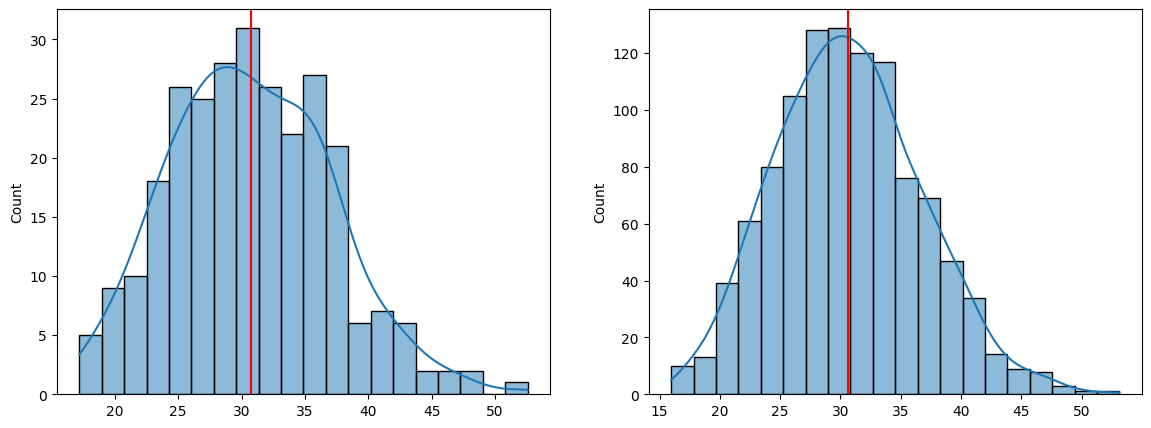

In [74]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(groups[0], kde=True, bins=20, ax=ax1)
ax1.axvline(x=group_means[0], color="r")
sns.histplot(groups[1], kde=True, bins=20, ax=ax2)
ax2.axvline(x=group_means[1], color="r")

plt.show()